In [1]:
import random
from typing import List, Tuple
import numpy as np
import matplotlib.pyplot as plt

In [2]:
def ga_8_queens(pop_size=50, generations=200, mutation_p=0.1, tournament_k=3, seed=1):
    random.seed(seed); np.random.seed(seed)
    N = 8
    max_fitness = 28  # C(8,2) non-attacking pairs

    def fitness(chrom: List[int]) -> int:
        # chrom: list length 8, values 0..7 (rows) for columns 0..7
        non_attacking = 0
        for i in range(N):
            for j in range(i + 1, N):
                if chrom[i] != chrom[j] and abs(chrom[i] - chrom[j]) != abs(i - j):
                    non_attacking += 1
        return non_attacking

    def random_chrom():
        return [random.randrange(N) for _ in range(N)]

    def tournament_select(pop, fits):
        idxs = random.sample(range(len(pop)), tournament_k)
        return pop[max(idxs, key=lambda i: fits[i])]

    def crossover(a, b):
        pt = random.randrange(1, N)
        child1 = a[:pt] + b[pt:]
        child2 = b[:pt] + a[pt:]
        return child1, child2

    def mutate(chrom):
        if random.random() < mutation_p:
            i = random.randrange(N)
            chrom[i] = random.randrange(N)

    # init
    pop = [random_chrom() for _ in range(pop_size)]
    best_history = []
    for gen in range(generations):
        fits = [fitness(c) for c in pop]
        best_idx = int(np.argmax(fits))
        best = pop[best_idx]; best_fit = fits[best_idx]
        best_history.append(best_fit)
        print(f"GA Gen {gen:03d} best fitness {best_fit}")
        if best_fit == max_fitness:
            print("Found perfect solution at generation", gen)
            break
        # elitism: keep top 2
        sorted_idx = sorted(range(pop_size), key=lambda i: fits[i], reverse=True)
        new_pop = [pop[sorted_idx[0]], pop[sorted_idx[1]]]
        while len(new_pop) < pop_size:
            p1 = tournament_select(pop, fits); p2 = tournament_select(pop, fits)
            c1, c2 = crossover(p1, p2)
            mutate(c1); mutate(c2)
            new_pop.extend([c1, c2])
        pop = new_pop[:pop_size]

    # final
    fits = [fitness(c) for c in pop]
    best_idx = int(np.argmax(fits)); best = pop[best_idx]; best_fit = fits[best_idx]
    print("GA Best fitness:", best_fit, "chromosome (0-index rows):", best)
    # visualize board
    board = np.zeros((N, N), dtype=int)
    for col, row in enumerate(best):
        board[row, col] = 1
    plt.figure(figsize=(4, 4))
    plt.imshow(board[::-1], cmap='Greys', interpolation='nearest')
    plt.title(f"GA 8-Queens best (fitness={best_fit})")
    plt.xticks(range(N)); plt.yticks(range(N))
    plt.show()
    plt.figure(); plt.plot(best_history, label='best fitness'); plt.xlabel('gen'); plt.ylabel('fitness'); plt.grid(True); plt.show()

In [3]:
def pso_tsp(num_cities=10, swarm_size=50, iterations=500, seed=2):
    random.seed(seed); np.random.seed(seed)
    # generate random city coords and distance matrix
    coords = np.random.rand(num_cities, 2) * 100
    dist = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))

    def tour_length(tour: List[int]) -> float:
        return sum(dist[tour[i], tour[(i + 1) % num_cities]] for i in range(num_cities))

    # permutation utilities: minimal swap sequence to turn a into b
    def swaps_to_transform(a: List[int], b: List[int]) -> List[Tuple[int,int]]:
        a = list(a)
        pos = {val:i for i,val in enumerate(a)}
        swaps=[]
        for i in range(len(b)):
            if a[i] != b[i]:
                j = pos[b[i]]
                swaps.append((i,j))
                # perform swap in a and update positions
                a[i], a[j] = a[j], a[i]
                pos[a[j]] = j; pos[a[i]] = i
        return swaps

    def apply_swaps(tour: List[int], swaps: List[Tuple[int,int]], keep_prob=0.5):
        tour = list(tour)
        for (i,j) in swaps:
            if random.random() < keep_prob:
                tour[i], tour[j] = tour[j], tour[i]
        return tour

    # init swarm
    swarm = [random.sample(range(num_cities), num_cities) for _ in range(swarm_size)]
    pbest = list(swarm)
    pbest_val = [tour_length(t) for t in swarm]
    gbest_idx = int(np.argmin(pbest_val))
    gbest = pbest[gbest_idx]
    gbest_val = pbest_val[gbest_idx]
    history = []
    for it in range(iterations):
        for i in range(swarm_size):
            # create velocity as swaps toward pbest and gbest
            s = swarm[i]
            sw_p = swaps_to_transform(s, pbest[i])
            sw_g = swaps_to_transform(s, gbest)
            # apply subset of swaps (probabilities control cognitive/social)
            new = apply_swaps(s, sw_p, keep_prob=0.5)
            new = apply_swaps(new, sw_g, keep_prob=0.3)
            # small random perturbation
            if random.random() < 0.2:
                a,b = random.sample(range(num_cities),2); new[a], new[b] = new[b], new[a]
            swarm[i] = new
            val = tour_length(new)
            if val < pbest_val[i]:
                pbest[i] = new; pbest_val[i] = val
                if val < gbest_val:
                    gbest = new; gbest_val = val
        history.append(gbest_val)
        if it%50==0:
            print(f"PSO iter {it:04d} best {gbest_val:.2f}")
    print("PSO best length:", gbest_val, "tour:", gbest)
    # plot convergence
    plt.figure(); plt.plot(history); plt.xlabel('iter'); plt.ylabel('best length'); plt.grid(True); plt.title('PSO-TSP convergence'); plt.show()
    # plot final path
    tour_coords = coords[gbest + [gbest[0]]]
    plt.figure(); plt.plot(tour_coords[:,0], tour_coords[:,1], '-o'); plt.title(f'PSO TSP best ({gbest_val:.2f})'); plt.show()

In [4]:
def aco_vrp(num_customers=10, ant_count=40, iterations=300, vehicle_capacity=4, seed=3):
    random.seed(seed); np.random.seed(seed)
    # generate depot + customers coordinates
    coords = np.random.rand(num_customers + 1, 2) * 100  # index 0 is depot
    n = num_customers + 1
    dist = np.sqrt(((coords[:, None, :] - coords[None, :, :]) ** 2).sum(axis=2))
    customers = list(range(1, n))
    # demands: all 1 for simplicity (capacity in number of customers)
    demand = {i:1 for i in customers}

    alpha = 1.0; beta = 5.0; rho = 0.5; Q = 100.0
    tau = np.ones((n, n))  # pheromone
    best_routes = None; best_cost = float('inf')
    history = []

    def route_cost(routes: List[List[int]]) -> float:
        total = 0.0
        for r in routes:
            if not r:
                continue
            prev = 0
            for c in r:
                total += dist[prev, c]; prev = c
            total += dist[prev, 0]
        return total

    def feasible_next(current, unvisited, load_left):
        # returns list of feasible customers
        return [c for c in unvisited if demand[c] <= load_left]

    for it in range(iterations):
        ants_routes = []
        ants_costs = []
        for a in range(ant_count):
            unvisited = set(customers)
            routes = []
            while unvisited:
                route = []
                load = vehicle_capacity
                current = 0
                feasible = feasible_next(current, unvisited, load)
                if not feasible:
                    # no feasible customers left for this route; break to avoid infinite loop
                    break
                while True:
                    feasible = feasible_next(current, unvisited, load)
                    if not feasible:
                        break
                    # probabilities over feasible next
                    probs = []
                    for c in feasible:
                        heur = (1.0 / (dist[current, c] + 1e-6)) ** beta
                        probs.append((tau[current, c] ** alpha) * heur)
                    probs = np.array(probs); probs /= probs.sum()
                    chosen = np.random.choice(feasible, p=probs)
                    route.append(chosen); unvisited.remove(chosen)
                    load -= demand[chosen]; current = chosen
                    if load <= 0:
                        break
                routes.append(route)
            cost = route_cost(routes)
            ants_routes.append(routes); ants_costs.append(cost)
            if cost < best_cost:
                best_cost = cost; best_routes = routes
        # pheromone evaporation
        tau *= (1 - rho)
        # pheromone deposit proportional to 1/cost
        for routes, cost in zip(ants_routes, ants_costs):
            if cost <= 0:
                continue
            deposit = Q / cost
            for r in routes:
                prev = 0
                for c in r:
                    tau[prev, c] += deposit; tau[c, prev] += deposit
                    prev = c
                tau[prev, 0] += deposit; tau[0, prev] += deposit
        history.append(best_cost)
        if it % 50 == 0:
            print(f"ACO iter {it:04d} best {best_cost:.2f}")

    # display best routes
    print("ACO best total distance:", best_cost)
    for i, r in enumerate(best_routes, 1):
        print(f"Vehicle {i}: 0 -> " + " -> ".join(map(str, r)) + " -> 0")
    plt.figure(); plt.plot(history); plt.xlabel('iter'); plt.ylabel('best distance'); plt.grid(True); plt.title('ACO-VRP convergence'); plt.show()
    # plot routes
    plt.figure(figsize=(6,6))
    for r in best_routes:
        if not r: continue
        path = [0] + r + [0]
        pc = coords[path]
        plt.plot(pc[:,0], pc[:,1], '-o')
    plt.scatter(coords[0,0], coords[0,1], c='red', s=80, label='depot')
    plt.title(f"ACO VRP best {best_cost:.2f}"); plt.legend(); plt.show()

=== PART A: GA 8-Queens ===
GA Gen 000 best fitness 24
GA Gen 001 best fitness 25
GA Gen 002 best fitness 25
GA Gen 003 best fitness 26
GA Gen 004 best fitness 26
GA Gen 005 best fitness 26
GA Gen 006 best fitness 27
GA Gen 007 best fitness 27
GA Gen 008 best fitness 27
GA Gen 009 best fitness 27
GA Gen 010 best fitness 28
Found perfect solution at generation 10
GA Best fitness: 28 chromosome (0-index rows): [3, 0, 4, 7, 1, 6, 2, 5]


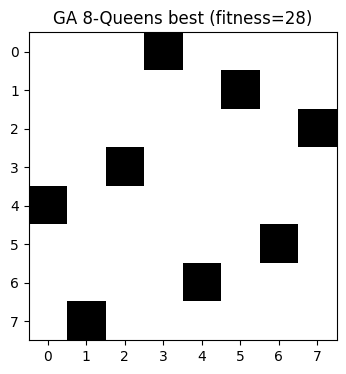

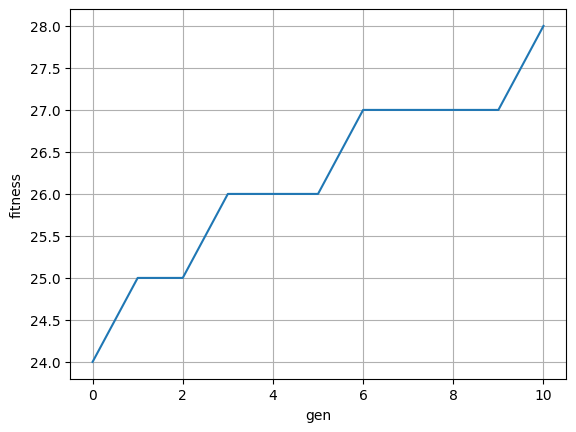

In [5]:
print("=== PART A: GA 8-Queens ===")
ga_8_queens(pop_size=50, generations=500, mutation_p=0.15, tournament_k=3, seed=1)


=== PART B: PSO TSP ===
PSO iter 0000 best 354.91
PSO iter 0050 best 272.65
PSO iter 0100 best 272.65
PSO iter 0150 best 272.65
PSO iter 0200 best 272.65
PSO iter 0250 best 272.65
PSO iter 0300 best 272.65
PSO iter 0350 best 272.65
PSO iter 0400 best 272.65
PSO iter 0450 best 272.65
PSO iter 0500 best 272.65
PSO iter 0550 best 272.65
PSO best length: 272.65075344579145 tour: [8, 5, 1, 2, 3, 7, 6, 4, 0, 9]


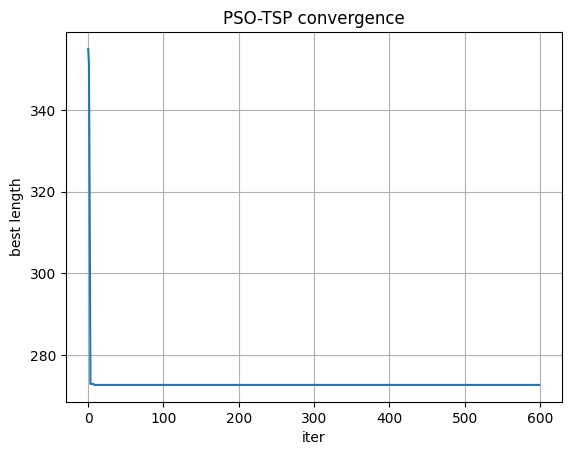

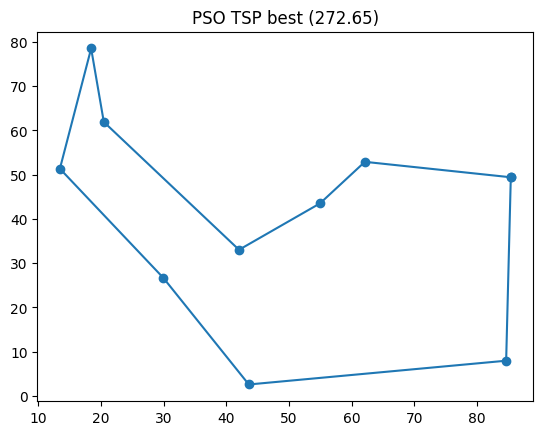

In [6]:
print("\n=== PART B: PSO TSP ===")
pso_tsp(num_cities=10, swarm_size=60, iterations=600, seed=2)


=== PART C: ACO VRP ===
ACO iter 0000 best 407.35
ACO iter 0050 best 392.03
ACO iter 0100 best 392.03
ACO iter 0150 best 392.03
ACO iter 0200 best 392.03
ACO iter 0250 best 392.03
ACO iter 0300 best 392.03
ACO iter 0350 best 392.03
ACO best total distance: 392.0314076111888
Vehicle 1: 0 -> 3 -> 4 -> 5 -> 8 -> 0
Vehicle 2: 0 -> 10 -> 1 -> 9 -> 6 -> 0
Vehicle 3: 0 -> 7 -> 2 -> 0


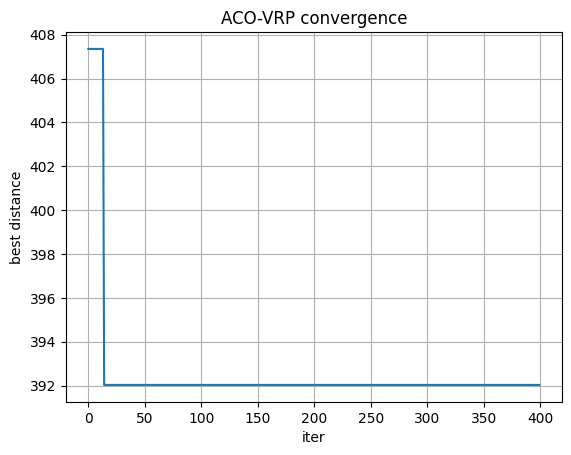

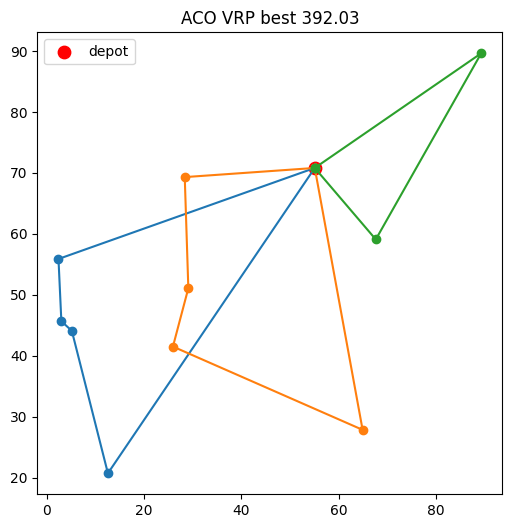

In [7]:
print("\n=== PART C: ACO VRP ===")
aco_vrp(num_customers=10, ant_count=60, iterations=400, vehicle_capacity=4, seed=3)